# Image Captioning — 01 Generating Captions

Automatically describe an image in natural language using a **pretrained Vision-Encoder-Decoder** model — a ViT image encoder feeding a GPT-2 text decoder (`nlpconnect/vit-gpt2-image-captioning`). No training needed; we run inference on sample images.

*(First run downloads ~1 GB of model weights and loads in ~1–2 minutes on CPU.)*

In [1]:
import glob
import matplotlib.pyplot as plt
from PIL import Image
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
model,processor,tokenizer=utils.load_model()
print('model loaded:',utils.MODEL_ID)

[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model loaded: nlpconnect/vit-gpt2-image-captioning


## 1. Caption the sample images

In [2]:
imgs=sorted(glob.glob('data/*.jpg')+glob.glob('data/*.png'))
caps={p:utils.caption_image(p,model,processor,tokenizer) for p in imgs}
for p,c in caps.items(): print(f'{p.split("/")[-1]:14s} -> {c}')

[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


bicycle.jpg    -> a man riding a bike next to a woman on a bike
cat.jpg        -> a cat that is looking at something
china.png      -> a tall building with a clock on top
dog.jpg        -> a white dog standing in a grassy field
flower.png     -> a flower in a vase on a sunny day
pizza.jpg      -> a pizza in a box on a table


## 2. Show images with their generated captions

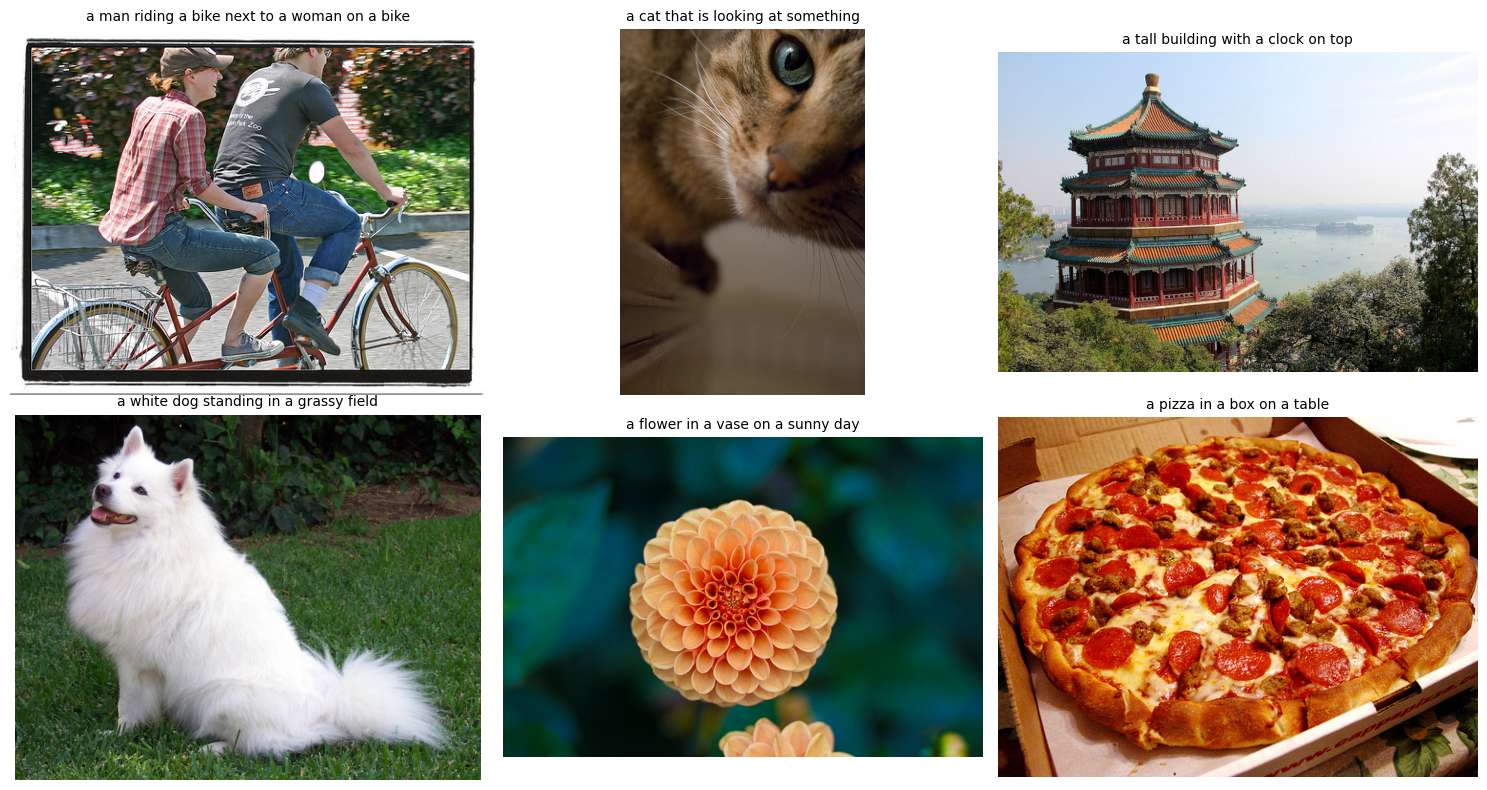

In [3]:
fig,ax=plt.subplots(2,3,figsize=(15,8))
for a,p in zip(ax.ravel(),imgs):
    a.imshow(Image.open(p)); a.axis('off'); a.set_title(caps[p],fontsize=10,wrap=True)
plt.tight_layout(); plt.show()

## 3. Summary & takeaways

- The pretrained ViT-GPT2 model produces **fluent, mostly-accurate captions** with zero training — e.g. *'a white dog standing in a grassy field'*, *'a pizza in a box on a table'*, *'a cat that is looking at something'*.
- **The encoder–decoder pattern**: the ViT turns the image into a sequence of patch embeddings; the GPT-2 decoder attends to those and generates text token-by-token (beam search picks the most likely caption).
- **Honest failure modes**: it describes *what it recognises*, so it can miss context or mislabel unfamiliar scenes — e.g. a dense cityscape captioned as *'a tall building with a clock on top'*. It reflects its training distribution (COCO-style everyday photos).
- This is transfer learning at its most useful: a heavyweight vision-language model, used off-the-shelf in a few lines, for a task that would otherwise need a large captioned dataset to train.